In [1]:
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import yticks
from sklearn.externals.array_api_compat.cupy import linspace

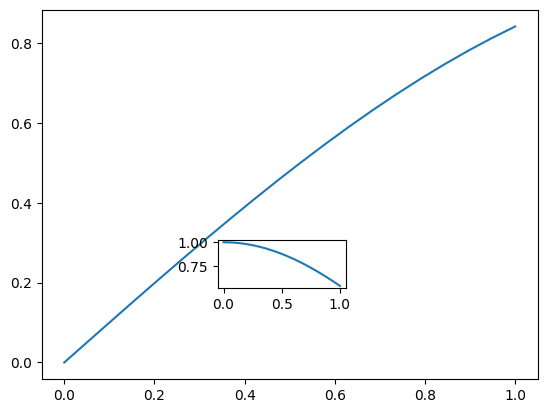

In [27]:
# субграфики матлабовские

ax1 = plt.axes()
# нижний левый ширина высота
# 0.4 - 40 проц ширины рисунка
# 0.3 - 30 проц высоты рисунка
ax2 = plt.axes([0.4, 0.3, 0.2, 0.1])
x = np.linspace(0, 1, 20)
ax1.plot(x, np.sin(x))
ax2.plot(x, np.cos(x))
plt.show()

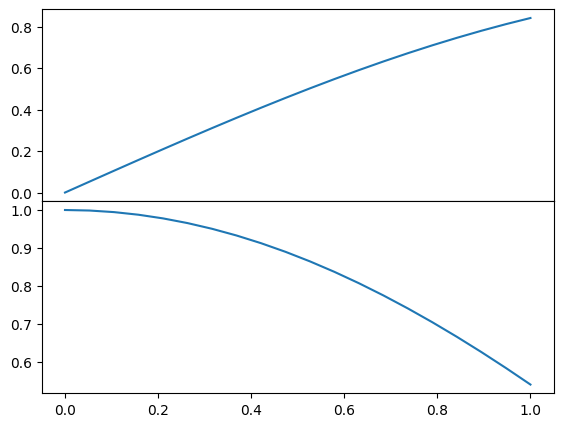

In [31]:
# субграфики ООП

fig = plt.figure()
ax1 = fig.add_axes([0.1, 0.5, 0.8, 0.4])
ax2 = fig.add_axes([0.1, 0.1, 0.8, 0.4])

ax1.plot(x, np.sin(x))
ax2.plot(x, np.cos(x))

plt.show()


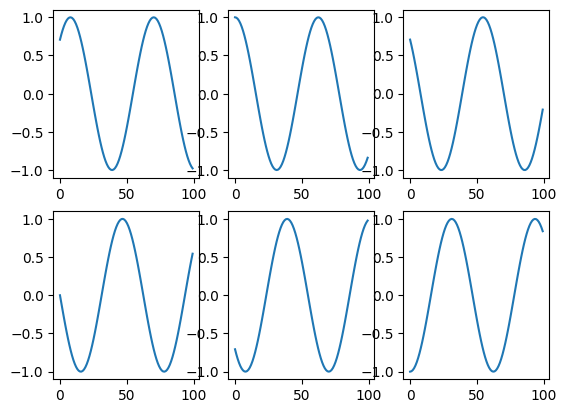

In [48]:
x = np.linspace(0, 10, 100)
fig = plt.figure()
for i in range(1,  7):
    ax = fig.add_subplot(2, 3, i)
    ax.plot(np.sin(x+np.pi/4*i))

plt.show()

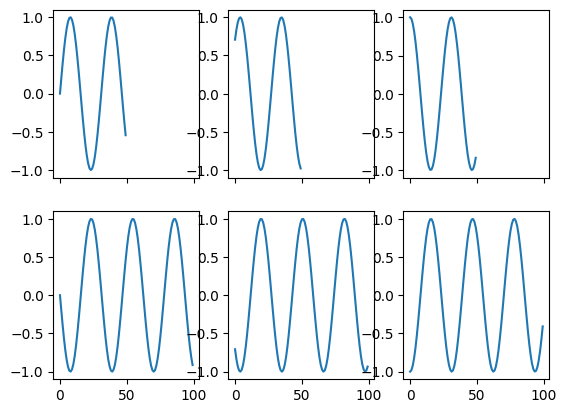

In [55]:
fig, ax = plt.subplots(2, 3, sharex = 'all')
x1 = np.linspace(0, 10, 50)
x2 = np.linspace(0, 20, 100)
for i in range(2):
    for j in range(3):
        if i%2 == 0:
           ax[i,j].plot(np.sin(x1 + np.pi/4*(i*2 + j)))
        else:
           ax[i,j].plot(np.cos(x2 + np.pi/4*(i*2 + j)))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

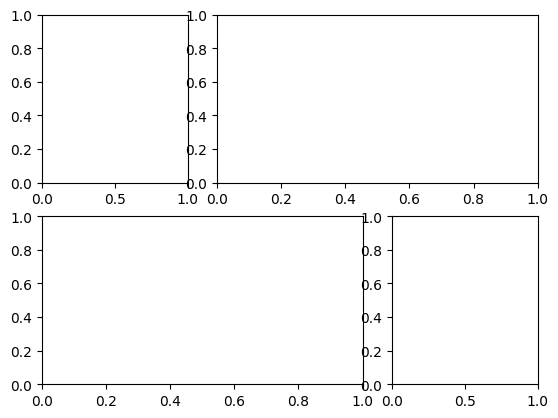

In [58]:
grid = plt.GridSpec(2, 3)

#   0 1 2
# 0 x y y
# 1 z z k
plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1:])
plt.subplot(grid[1, :2])
plt.subplot(grid[1, 2])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

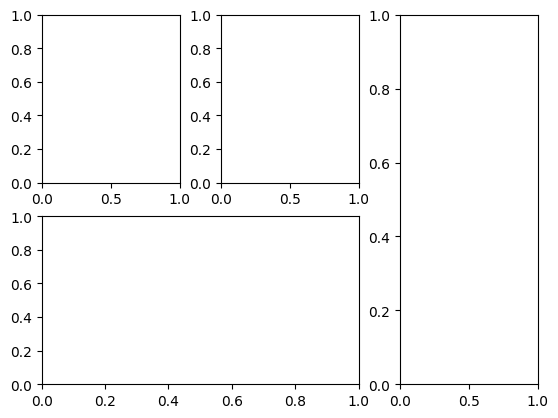

In [63]:
grid = plt.GridSpec(2, 3, wspace=0.3)

#   0 1 2
# 0 x y k
# 1 z z k
plt.subplot(grid[0, 0])
plt.subplot(grid[0, 1])
plt.subplot(grid[:, 2])
plt.subplot(grid[1, :2])
plt.show

/var/folders/6p/5mscwz31629gyb0h0hz8t8xw0000gn/T/ipykernel_1413/1747002486.py:10: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  x, y = rng.multivariate_normal([0, 0], [[1, 2], [3, 4]], 1000).T


<function matplotlib.pyplot.show(close=None, block=None)>

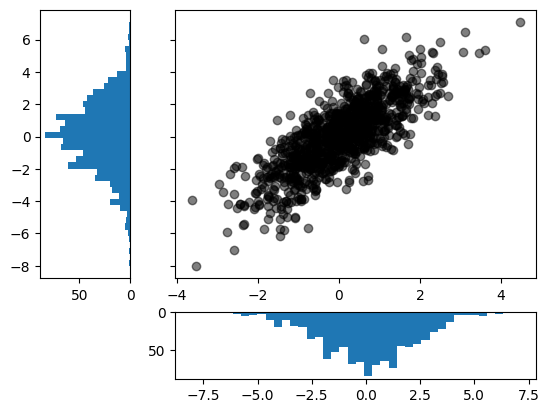

In [82]:
grid = plt.GridSpec(4, 4, wspace=0.5, hspace=0.5)

# z x x x
# z x x x
# z x x x
#   y y y


rng = np.random.default_rng(1)
x, y = rng.multivariate_normal([0, 0], [[1, 2], [3, 4]], 1000).T

main_axes = plt.subplot(grid[:3, 1:], yticklabels = []) # x
y_axes = plt.subplot(grid[:3, 0])  # y
x_axes = plt.subplot(grid[3, 1:]) # z

main_axes.plot(x, y, "ok", alpha=0.5)
y_axes.hist(y, 40, orientation="horizontal")
y_axes.invert_xaxis()
x_axes.hist(y, 40)
x_axes.invert_yaxis()

plt.show

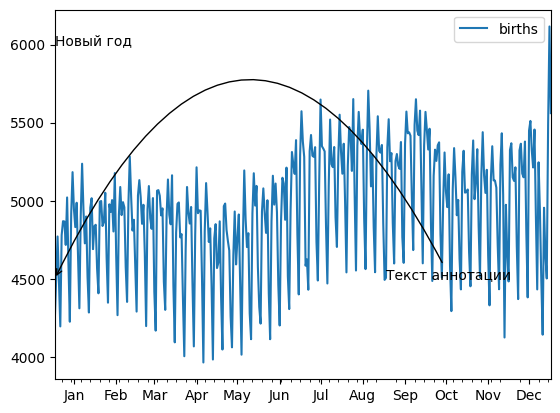

In [121]:
births = pd.read_csv("/Users/adil.murat/PycharmProjects/ml_formula/data/births.csv")
births["day"] = births["day"].astype(int)
births.index = pd.to_datetime(births["year"] * 10000 + births["month"] * 100 + births["day"], format="%Y%m%d")

births_dom = births.pivot_table("births", index=[births.index.month, births.index.day])
from datetime import datetime
births_dom.index = [datetime(1969, month, day) for (month, day) in births_dom.index]

fig, ax = plt.subplots()
births_dom.plot(ax=ax)

ax.text('1969-01-01', 6000, 'Новый год')

ax.xaxis.set_major_locator(mpl.dates.MonthLocator(bymonthday = 15))
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%h"))

ax.annotate('Текст аннотации',xy=('1969-01-01', 4500), xytext=('1969-9-01', 4500), arrowprops = dict(arrowstyle ="->", facecolor='black', connectionstyle='arc3,rad=1'))

plt.show()

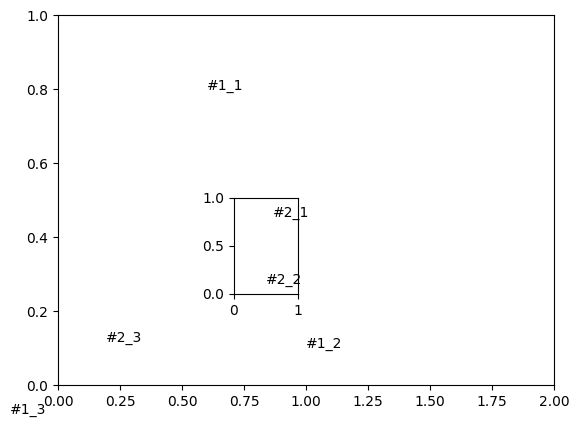

In [131]:
fig = plt.figure()
ax1 = plt.axes()
ax1.set_xlim(0,2)
ax2 = plt.axes([0.4, 0.3, 0.1, 0.2])

ax1.text(0.6, 0.8, '#1_1', transform=ax1.transData)
ax2.text(0.6, 0.8, '#2_1', transform=ax2.transData)

ax1.text(0.5, 0.1, '#1_2', transform=ax1.transAxes)
ax2.text(0.5, 0.1, '#2_2', transform=ax2.transAxes)

ax1.text(0.05, 0.05, '#1_3', transform=fig.transFigure)
ax2.text(0.2, 0.2, '#2_3', transform=fig.transFigure)

plt.show()